<a href="https://colab.research.google.com/github/Integenpiyush/churn-prediction-catboost/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install catboost optuna shap wandb imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 24.8 MB/s eta 0:00:00
All libraries loaded successfully


## Customer Churn Prediction — EDA
**Goal:** Understand the dataset, find patterns related to churn,
and identify which features matter before building any model.

In [2]:
df = pd.read_csv('/content/telco_churn.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


**Shape :** (7043,21),rows = 7043 and columns = 21


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Observations from df.info()
- Dataset has 7043 rows and 21 columns
- Target column: Churn (Yes/No)
- TotalCharges looks like it should be numeric but shows as object — needs fixing
- customerID is not useful for prediction — will drop it
- SeniorCitizen is stored as int (0/1) but is categorical in nature

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Observations:
 1. SeniorCitizen is stored as numerical (0/1) but represents a categorical feature.
 2. Average customer tenure is around 32 months.
 3. MonthlyCharges vary significantly among customers (std ≈ 30).
 4. MonthlyCharges median (70.35) is higher than mean (64.76), indicating slight left skewness.
 5. Tenure ranges from 0 to 72 months, showing both new and long-term customers exist.
 6. Most customers are not senior citizens since mean of SeniorCitizen is only 0.16 (~16%).
 7. TotalCharges is missing from numerical summary, likely due to incorrect datatype (object).



In [6]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True).round(3)*100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


## Class Imbalance
- No churn: 73.5%
- Churn: 26.5%
- This means if a model predicts "No" for everyone,
  it gets 73.5% accuracy without learning anything.
- This is why we cannot use accuracy alone as our metric.
- We will use Recall,Precision,F1-score and AUC-ROC instead.
- We will use SMOTE on training data to handle this imbalance.

## Day 2 — Data Cleaning

In [7]:
# drop customerID
df=df.drop(columns=['customerID'])
print("customerID dropped. New shape:", df.shape)

customerID dropped. New shape: (7043, 20)


In [8]:
# Fix TotalCharges
print("Before fix:")
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].unique()[:10])

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nAfter fix:")
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].unique()[:10])
print("Null values created:", df['TotalCharges'].isnull().sum())

Before fix:
object
['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95']

After fix:
float64
[  29.85 1889.5   108.15 1840.75  151.65  820.5  1949.4   301.9  3046.05
 3487.95]
Null values created: 11


In [9]:
# Check which rows have null TotalCharges
print(df[df['TotalCharges'].isnull()])

      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
488   Female              0     Yes        Yes       0           No   
753     Male              0      No        Yes       0          Yes   
936   Female              0     Yes        Yes       0          Yes   
1082    Male              0     Yes        Yes       0          Yes   
1340  Female              0     Yes        Yes       0           No   
3331    Male              0     Yes        Yes       0          Yes   
3826    Male              0     Yes        Yes       0          Yes   
4380  Female              0     Yes        Yes       0          Yes   
5218    Male              0     Yes        Yes       0          Yes   
6670  Female              0     Yes        Yes       0          Yes   
6754    Male              0      No        Yes       0          Yes   

         MultipleLines InternetService       OnlineSecurity  \
488   No phone service             DSL                  Yes   
753                 N

## TotalCharges Fix
- TotalCharges was stored as object due to blank spaces in some rows
- Fixed using pd.to_numeric with errors='coerce'
- 11 rows became NaN after conversion
- These rows have tenure = 0 (new customers, no charges yet)
- Decision: drop these rows since they are new customers
  with no usage history — not useful for churn prediction

In [10]:
df=df.dropna(subset=['TotalCharges'])
print("Shape after dropping nulls:", df.shape)

Shape after dropping nulls: (7032, 20)


In [11]:
# Fix SeniorCitizen
print("Before:", df['SeniorCitizen'].dtype)
print(df['SeniorCitizen'].value_counts())

df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
print("\nAfter:", df['SeniorCitizen'].value_counts())

Before: int64
SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

After: SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64


In [12]:
# Fix target column
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [13]:
print("Final shape:", df.shape)
print("\nAny nulls remaining?")
print(df.isnull().sum().sum())
print("\nData types:")
print(df.dtypes.value_counts())

Final shape: (7032, 20)

Any nulls remaining?
0

Data types:
object     16
int64       2
float64     2
Name: count, dtype: int64


## Data Cleaning Summary
- Dropped customerID (not a predictive feature)
- Fixed TotalCharges from object to float64
- Dropped 11 rows with blank TotalCharges (new customers, tenure=0)
- Converted SeniorCitizen from 0/1 integer to No/Yes categorical
- Converted Churn target from Yes/No to 1/0 for modeling
- Final dataset: 7032 rows, 20 columns, 0 null values

## Day 3 — Univariate Analysis
Understanding the distribution of each feature individually.

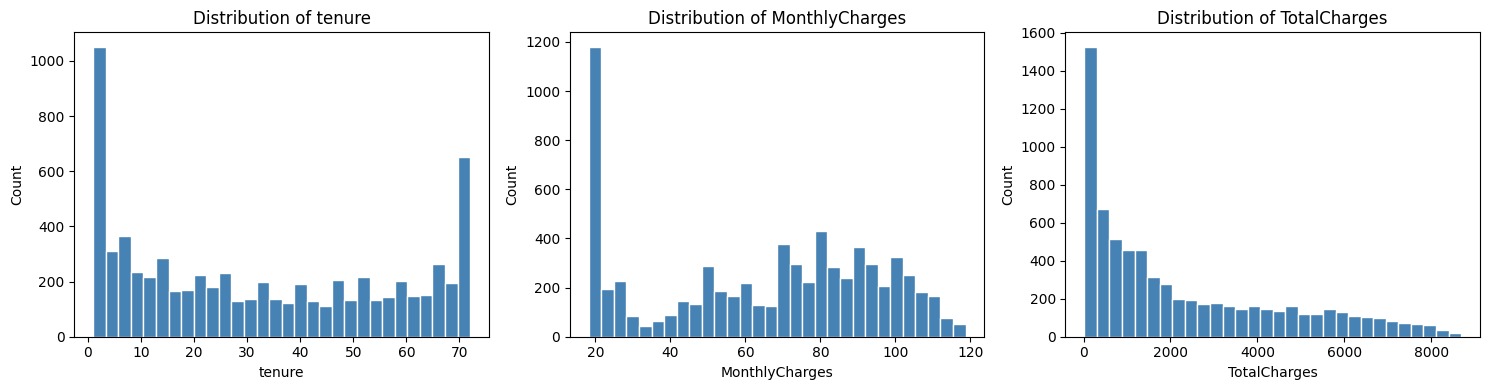

In [14]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1,3,figsize=(15,4))
for i,col in enumerate(numerical_cols):
  axes[i].hist(df[col],bins=30,color='steelblue',edgecolor='white')
  axes[i].set_title(f'Distribution of {col}')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Count')


plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## Numerical Column Observations
- tenure: bimodal — spike at 0-5 months (new customers likely to churn)
  and another spike at 70+ months (loyal customers, unlikely to churn).
  This alone is a strong churn signal — low tenure = high churn risk.
- MonthlyCharges: roughly uniform with a spike at low end.
  Suggests two customer segments — basic and premium plans.
- TotalCharges: right-skewed. Most customers have low total charges,
  few have very high (long tenure × high monthly = high total).


Churn rate by Contract type:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


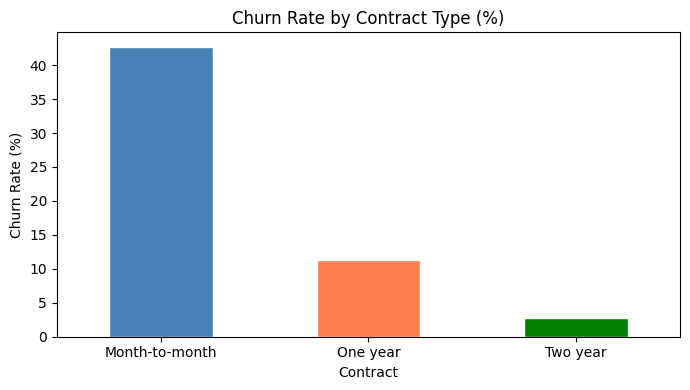

In [15]:
# Churn rate by Contract type
contract_churn = df.groupby('Contract')['Churn'].mean().round(3)*100
print("Churn rate by Contract type:")
print(contract_churn)


plt.figure(figsize=(7, 4))
contract_churn.plot(kind='bar',color=['steelblue','coral','green'],edgecolor='white')
plt.title('Churn Rate by Contract Type (%)')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

Churn rate by Internet Service:
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64


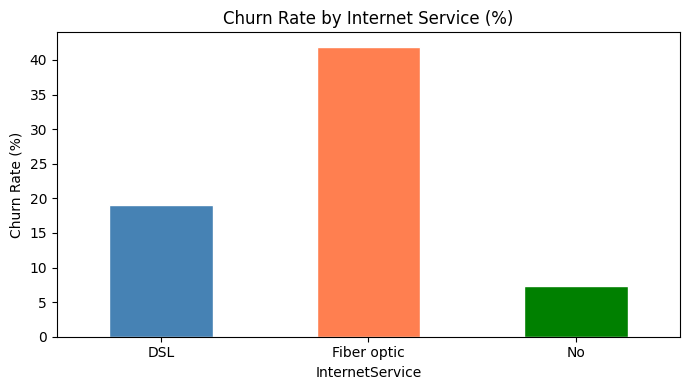

In [16]:
#  Churn rate by Internet Service
internet_churn = df.groupby('InternetService')['Churn'].mean().round(3)*100
print("Churn rate by Internet Service:")
print(internet_churn)

plt.figure(figsize=(7,4))
internet_churn.plot(kind='bar', color=['steelblue','coral','green'],
                    edgecolor='white')
plt.title('Churn Rate by Internet Service (%)')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
# Churn rate by Payment Method
payment_churn = df.groupby('PaymentMethod')['Churn'].mean().round(3) * 100
print("Churn rate by Payment Method:")
print(payment_churn)

Churn rate by Payment Method:
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.3
Electronic check             45.3
Mailed check                 19.2
Name: Churn, dtype: float64


## Key Univariate Findings — The 3 Most Important Churn Signals

1. Contract type is the strongest predictor:
   - Month-to-month: 42.7% churn
   - One year: 11.3% churn
   - Two year: 2.8% churn
   - Insight: Month-to-month customers churn 15x more than two-year customers.
     No long-term commitment = easy to leave.

2. Internet service type matters:
   - Fiber Optic: 41.9% churn (high — possibly due to higher cost)
   - DSL: 19.0% churn
   - No internet: 7.4% churn
   - Insight: Fiber optic customers pay more (seen in MonthlyCharges)
     and churn almost as much as month-to-month contracts.

3. Payment method reveals intent:
   - Electronic check: 45.3% churn (highest)
   - Mailed check: 19.2%
   - Auto-payment customers: ~15-16% churn (lowest)
   - Insight: Customers on auto-payment are more committed.
     Electronic check = no friction to cancel.



"what was your most important EDA finding?",
"Contract type was the single strongest signal — month-to-month customers churned at 42.7% versus only 2.8% for two-year contracts — a 15x difference. Combined with payment method, where electronic check customers churned at 45.3% versus 15-16% for auto-payment customers, it was clear that customer commitment level — both contractual and behavioral — is the core driver of churn."


In [18]:
#  Categorical columns overview
categorical_cols = df.select_dtypes(include='object').columns.tolist()

if 'Churn' in categorical_cols:
  categorical_cols.remove('Churn')
else:
  None

print("Categorical columns:", categorical_cols)
print("Count:", len(categorical_cols))

Categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Count: 16


In [19]:
df.to_csv('telco_cleaned.csv',index=False)
print("Cleaned data saved. Shape:", df.shape)

Cleaned data saved. Shape: (7032, 20)


## Day 4 — Bivariate Analysis
How do individual features relate to churn?
Finding which features are most predictive.

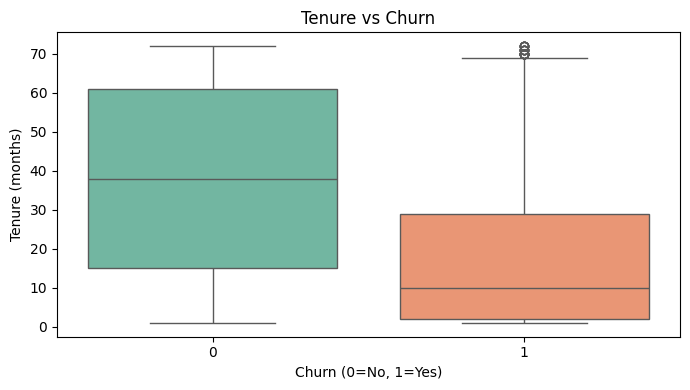

Median tenure — No churn: 38.0
Median tenure — Churn: 10.0


In [20]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Churn',y='tenure',data=df,palette='Set2')
plt.title('Tenure vs Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Tenure (months)')
plt.tight_layout()
plt.savefig('tenure_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()


print("Median tenure — No churn:", df[df['Churn']==0]['tenure'].median())
print("Median tenure — Churn:", df[df['Churn']==1]['tenure'].median())

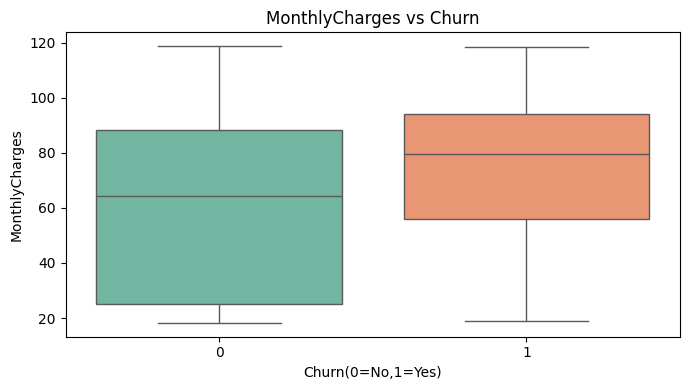

Median MonthlyCharges — No churn: 64.45
Median MonthlyCharges — Churn: 79.65


In [21]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Churn',y='MonthlyCharges',data=df,palette='Set2')
plt.title('MonthlyCharges vs Churn')
plt.xlabel('Churn(0=No,1=Yes)')
plt.ylabel('MonthlyCharges')
plt.tight_layout()
plt.show()

print("Median MonthlyCharges — No churn:", df[df['Churn']==0]['MonthlyCharges'].median())
print("Median MonthlyCharges — Churn:", df[df['Churn']==1]['MonthlyCharges'].median())

When asked "what did your EDA show?" you say:
"Churned customers had a median tenure of just 10 months versus 38 months for retained customers — a 3.8x difference. They also paid higher monthly charges on average — $79.65 versus $64.45. This told me that new, high-paying customers are the most at-risk segment."

### Box Plot
- Iqr = Q3-Q1, values outside this (Q1-1.5IQR,Q3+1.5IQR) are outliers.Q1(25%) ,Q2(50%)or median,and Q3(75%)

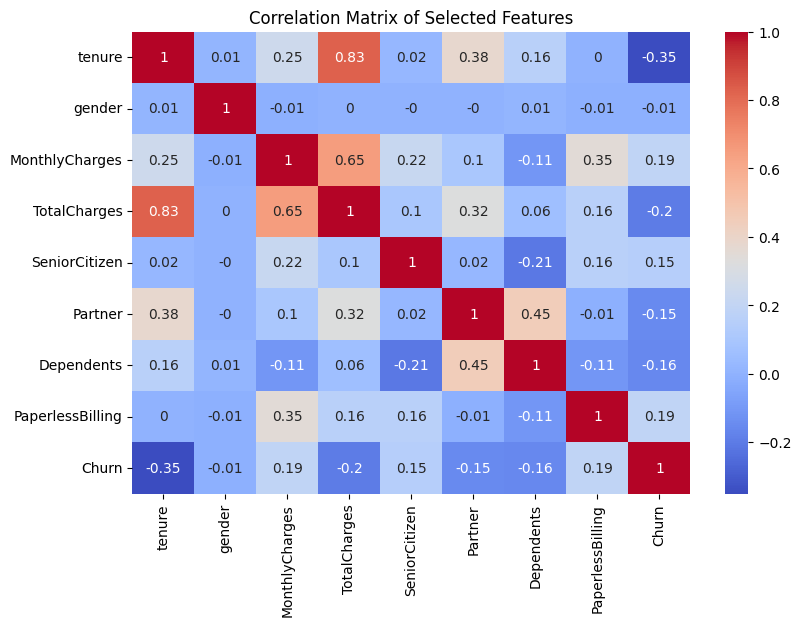

In [22]:
# Encode binary categoricals temporarily for correlation
df_corr = df.copy()

binary_cols = ['SeniorCitizen', 'Partner', 'Dependents',
               'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    # Assuming 'Yes' is the positive class for these columns
    # For PhoneService, 'No phone service' will also be mapped to 0
    df_corr[col] = (df_corr[col] == 'Yes').astype(int)

# Fix: Assign the encoded 'gender' back to the 'gender' column in df_corr
# The original 'gender' column uses 'Male' and 'Female'.
df_corr['gender'] = (df_corr['gender'] == 'Male').astype(int)

# Keep only numerical + binary encoded columns
corr_cols = ['tenure','gender', 'MonthlyCharges', 'TotalCharges',
             'SeniorCitizen', 'Partner', 'Dependents',
             'PaperlessBilling', 'Churn']
plt.figure(figsize=(9,6))
sns.heatmap(df_corr[corr_cols].corr().round(2), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Selected Features')
plt.show()

## Correlation Heatmap Observations
- TotalCharges and tenure are highly correlated (~0.83) — makes sense,
  longer tenure = more total charges accumulated.
  Risk: multicollinearity. Will consider dropping TotalCharges later.
- TotalCharges and MonthlyCharges are also correlated (~0.65).
- Churn correlates negatively with tenure — longer customers stay less likely to churn.
- Churn correlates positively with MonthlyCharges — higher bill = more likely to leave.

In [23]:
# High risk segment analysis

# The most dangerous combination — find their churn rate
high_risk = df.groupby(['Contract',
                         'InternetService',
                         'PaymentMethod'])['Churn'].mean().round(3) * 100

# Show top 10 highest churn rate combinations
print("Top 10 highest churn rate customer segments:")
print(high_risk.sort_values(ascending=False).head(10))




Top 10 highest churn rate customer segments:
Contract        InternetService  PaymentMethod            
Month-to-month  Fiber optic      Electronic check             60.4
                                 Mailed check                 50.7
                                 Bank transfer (automatic)    45.6
                                 Credit card (automatic)      41.6
                DSL              Electronic check             40.5
                                 Mailed check                 30.8
                                 Credit card (automatic)      27.0
One year        Fiber optic      Electronic check             26.0
Month-to-month  No               Mailed check                 20.6
                                 Bank transfer (automatic)    20.0
Name: Churn, dtype: float64


## Highest Risk Customer Segment
- Month-to-month + Fiber Optic + Electronic Check = 60.4% churn rate
- This means 6 out of every 10 customers in this segment leave.
- Compared to overall churn of 26.5% — this segment churns 2.3x more.
- Business insight: A telecom company should immediately target this
  segment with retention offers — contract upgrades, bill discounts,
  or switching to auto-payment incentives.

In [24]:
# gender analysis

print("Churn rate by Gender:")
print(df.groupby('gender')['Churn'].mean().round(3) * 100)

Churn rate by Gender:
gender
Female    27.0
Male      26.2
Name: Churn, dtype: float64


## Gender Analysis — A Negative Finding
- Female: 27.0% churn, Male: 26.2% churn
- Difference of only 0.8% — essentially identical.
- Conclusion: Gender has no predictive power for churn.
- This is a valuable finding — it tells us what NOT to focus on.
- Gender will likely have very low SHAP importance in our final model.

## Day 4 Complete — Bivariate Analysis Summary

### Numerical features vs Churn:
- Tenure: churned customers median 10 months vs 38 months retained — 3.8x difference
- MonthlyCharges: churned customers pay $79.65 vs $64.45 retained — higher bill = higher risk

### Multicollinearity warning:
- TotalCharges vs tenure correlation: 0.83 (very high)
- TotalCharges vs MonthlyCharges correlation: 0.65 (high)
- Decision: will consider dropping TotalCharges during feature engineering
  since it carries redundant information already captured by tenure + MonthlyCharges

### Highest risk segment:
- Month-to-month + Fiber Optic + Electronic Check = 60.4% churn
- 2.3x higher than overall churn rate of 26.5%

### Negative finding:
- Gender has no predictive power — 27.0% vs 26.2% (0.8% difference)
- Churn is driven by service choices and contracts, not demographics

## Day 5 — Outlier Detection + Deep EDA

In [35]:
#  IQR outlier detection
def detect_outliers_iqr(df,col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3-Q1
  lower = Q1-1.5*IQR
  upper = Q3+1.5*IQR
  outliers = df[(df[col]<lower)|(df[col]>upper)]

  print(f'{col}:')
  print(f'Q1={Q1:.2f},Q3={Q3:.2f},IQR={IQR:.2f}')
  print(f"  Outliers found: {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%)")
  print()

for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
  detect_outliers_iqr(df, col)

tenure:
Q1=9.00,Q3=55.00,IQR=46.00
  Outliers found: 0 rows (0.00%)

MonthlyCharges:
Q1=35.59,Q3=89.86,IQR=54.27
  Outliers found: 0 rows (0.00%)

TotalCharges:
Q1=401.45,Q3=3794.74,IQR=3393.29
  Outliers found: 0 rows (0.00%)



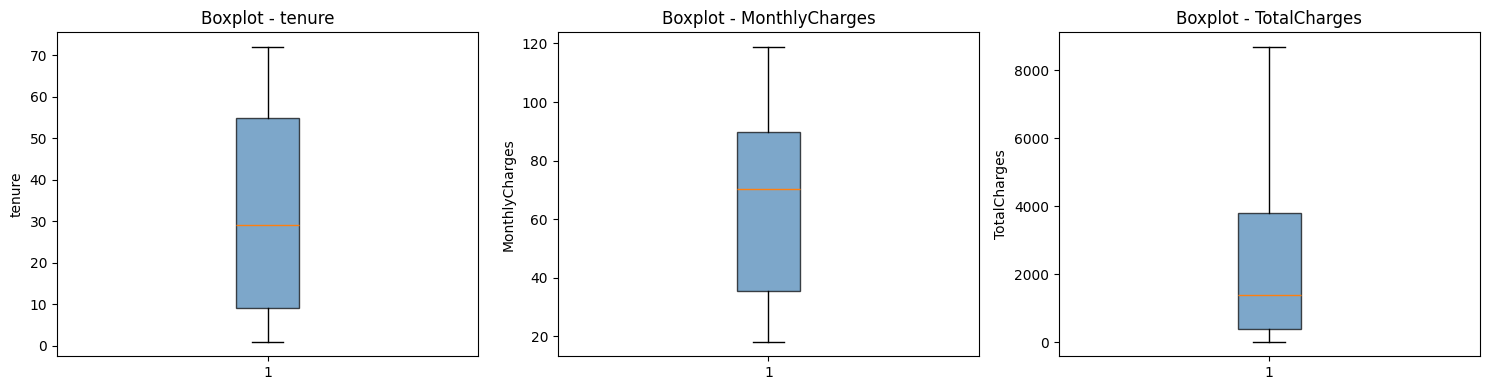

In [33]:
#  Boxplots for outlier visualization
fig,axes = plt.subplots(1,3,figsize=(15,4))

for i,col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
  axes[i].boxplot(df[col],patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
  axes[i].set_title(f'Boxplot - {col}')
  axes[i].set_ylabel(col)


plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


## Outlier Analysis
- tenure: 0 outliers (0.00%)
- MonthlyCharges: 0 outliers (0.00%)
- TotalCharges: 0 outliers (0.00%)

Finding: No outliers detected using IQR method.
Reason: Telecom billing data is naturally bounded —
- tenure is capped at the company's age (72 months max here)
- MonthlyCharges has natural plan-based price tiers
- TotalCharges = tenure × MonthlyCharges, so it inherits those bounds

This is actually a sign of clean, real-world operational data
as opposed to survey data or scraped data which often has outliers.
No outlier treatment needed — proceed directly to preprocessing.

In [43]:
# Which additional services reduce churn?
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']
churn_by_service = {}
for service in services:
  # Only Yes/No, exclude 'No internet service'
  temp = df[df[service]!='No internet service']
  churn_by_service[service] = temp.groupby(service)['Churn'].mean().round(3)*100

service_df = pd.DataFrame(churn_by_service).T
print("Churn rate by additional service (Yes vs No):")
print(service_df)

Churn rate by additional service (Yes vs No):
                    No   Yes
OnlineSecurity    41.8  14.6
OnlineBackup      39.9  21.6
DeviceProtection  39.1  22.5
TechSupport       41.6  15.2
StreamingTV       33.5  30.1
StreamingMovies   33.7  30.0


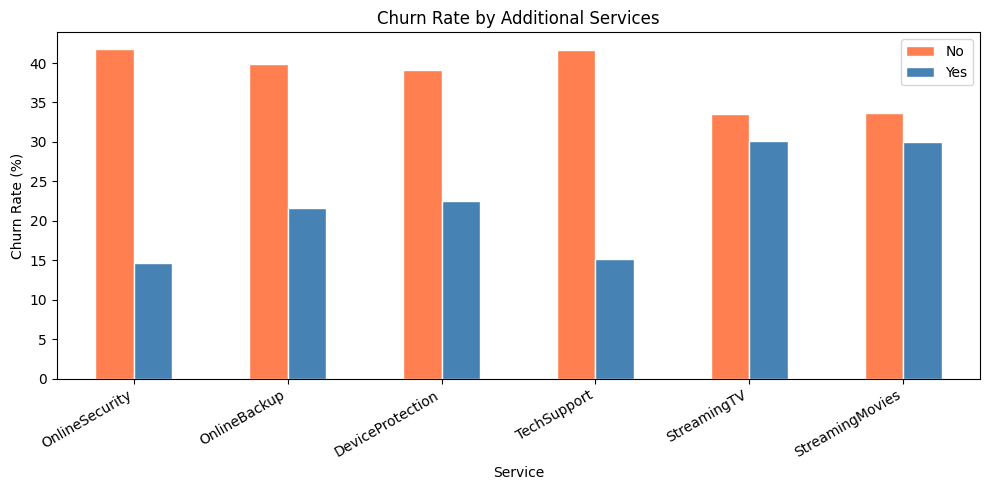

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
service_df.plot(kind='bar',ax=ax,color=['coral','steelblue'],edgecolor='white')
plt.title('Churn Rate by Additional Services')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Service')
plt.xticks(rotation=30, ha='right')
plt.legend(['No', 'Yes'])
plt.tight_layout()
plt.savefig('services_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## Services Insight — Retention Anchors
- OnlineSecurity: WITHOUT = 41.8% churn, WITH = 14.6% churn (2.9x difference)
- TechSupport: WITHOUT = 41.6% churn, WITH = 15.2% churn (2.7x difference)
- OnlineBackup: WITHOUT = 39.9% churn, WITH = 21.6% churn
- DeviceProtection: WITHOUT = 39.1% churn, WITH = 22.5% churn
- StreamingTV: WITHOUT = 33.5% churn, WITH = 30.1% churn (tiny difference)
- StreamingMovies: WITHOUT = 33.7% churn, WITH = 30.0% churn (tiny difference)

Pattern: Security and support services are strong retention anchors.
Customers without OnlineSecurity churn at nearly 3x the rate of
those with it. Streaming services show almost no difference —
entertainment is easily replaceable, security/support is not.

Business recommendation: Telecom company should bundle OnlineSecurity
and TechSupport into base plans or offer them free for 3 months —
the retention value far outweighs the cost.

In [47]:
# Senior citizen deep dive
print("Senior citizen churn rate:")
print(df.groupby('SeniorCitizen')['Churn'].mean().round(3)*100)
print("\nSenior citizen + Fiber optic churn rate:")
df.groupby(['SeniorCitizen','InternetService'])['Churn'].mean().round(3)*100

Senior citizen churn rate:
SeniorCitizen
No     23.7
Yes    41.7
Name: Churn, dtype: float64

Senior citizen + Fiber optic churn rate:


SeniorCitizen  InternetService
No             DSL                17.7
               Fiber optic        39.9
               No                  7.4
Yes            DSL                30.1
               Fiber optic        47.3
               No                  9.6
Name: Churn, dtype: float64

## Senior Citizen Analysis
- Senior citizens churn at 41.7% vs 23.7% for non-seniors — 1.76x higher
- Senior + Fiber Optic is the second highest risk segment: 47.3% churn
- Non-senior + No internet is the safest segment: only 7.4% churn

Why seniors churn more on Fiber Optic:
- Fiber optic = highest monthly charges
- Seniors on fixed incomes are more price-sensitive
- Combined with month-to-month contracts = very high exit risk

Business recommendation: Senior customers on Fiber Optic +
month-to-month should be first priority for retention calls
and discount offers.

## Complete EDA Summary — 7 Key Findings

**Dataset:** 7,032 telecom customers, 20 features, 26.5% churn rate

### Finding 1 — Class Imbalance
- 73.5% No churn, 26.5% churn
- Accuracy alone is misleading — will use F1 and AUC-ROC
- Will apply SMOTE on training data to handle imbalance

### Finding 2 — Contract Type (Strongest Signal)
- Month-to-month: 42.7% churn
- One year: 11.3% churn
- Two year: 2.8% churn
- 15x difference between month-to-month and two-year customers

### Finding 3 — Tenure and Monthly Charges
- Churned customers: median tenure 10 months, median bill $79.65
- Retained customers: median tenure 38 months, median bill $64.45
- New + high-paying customers are the most at-risk

### Finding 4 — Highest Risk Segment
- Month-to-month + Fiber Optic + Electronic Check = 60.4% churn
- 2.3x higher than overall average
- 6 in 10 customers in this segment leave

### Finding 5 — Security Services as Retention Anchors
- Without OnlineSecurity: 41.8% churn
- With OnlineSecurity: 14.6% churn — 2.9x difference
- TechSupport shows same pattern: 41.6% vs 15.2%
- Streaming services show almost no difference

### Finding 6 — Senior Citizens
- Senior citizens churn at 41.7% vs 23.7% for non-seniors
- Senior + Fiber Optic = 47.3% churn — second highest risk segment

### Finding 7 — Gender (Negative Finding)
- Female: 27.0%, Male: 26.2% — 0.8% difference
- Gender has no predictive power
- Churn is driven by service choices, not demographics

### Multicollinearity Note
- TotalCharges vs tenure: 0.83 correlation
- TotalCharges vs MonthlyCharges: 0.65 correlation
- Will consider dropping TotalCharges in feature engineering

### What This Means for Modeling
- Features to watch: Contract, tenure, MonthlyCharges,
  InternetService, OnlineSecurity, TechSupport, PaymentMethod
- Features likely low importance: gender, PhoneService
- Need SMOTE for class imbalance
- Need to handle TotalCharges multicollinearity